# Top-NMF: Example 2

The example uses a synthetic edge-weighted graph dataset with three overlapping cliques.


## Paper Hyperparameters
The following hyperparameters were used in the paper:
- `{n_components: 3, alpha: 1.0, lambda_top: 0.01}`
- `{n_components: 5, alpha: 0.1, lambda_top: 0.05}`
- `{n_components: 5, alpha: 1.0, lambda_top: 0.05}`
- `{n_components: 5, alpha: 5.0, lambda_top: 0.01}`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import torch
from itertools import combinations

from TopNMF import *

In [2]:
def generate_clique_dataset(
    cliques=((1, 2, 3, 4, 5), (5, 6, 7), (6, 7, 8, 9)),
    weights=((2, 1, 2), (1, 2, 1), (1, 1, 2)),
):
    all_nodes = sorted({i for clique in cliques for i in clique})
    edge_list = [tuple(sorted(e)) for e in combinations(all_nodes, 2)]
    edge_index = {e: i for i, e in enumerate(edge_list)}
    X = []

    for alpha in weights:
        row = np.zeros(len(edge_list))
        for coeff, clique in zip(alpha, cliques):
            for u, v in combinations(clique, 2):
                row[edge_index[tuple(sorted((u, v)))]] += coeff
        X.append(row)

    return np.stack(X), edge_list

X, all_edges = generate_clique_dataset()
print(f"X shape: {X.shape}, edges: {len(all_edges)}")


X shape: (3, 36), edges: 36


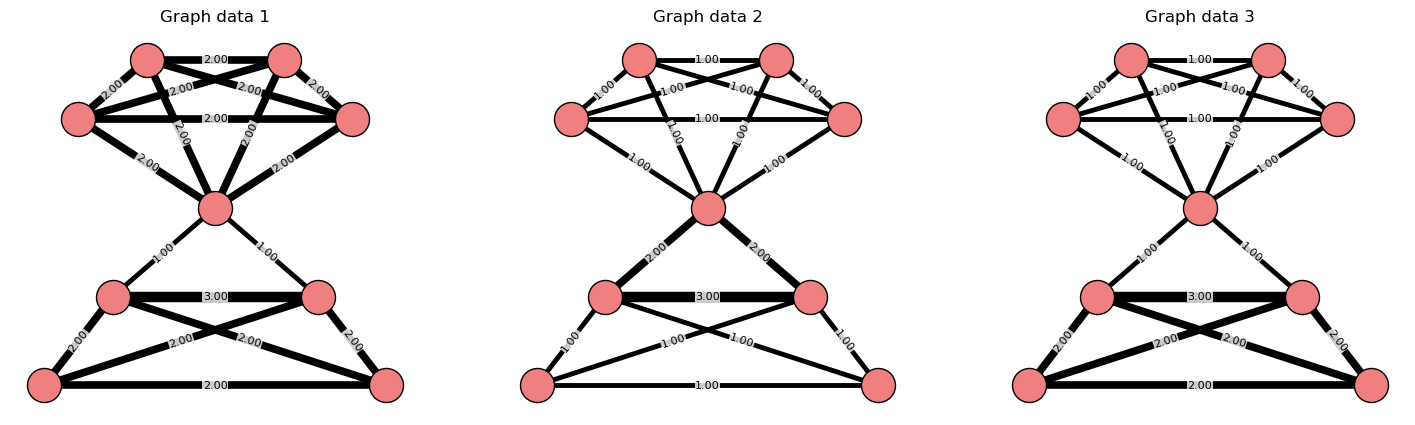

In [3]:
# Fixed node coordinates for consistent layouts
fixed_pos = {
    5: (0, 0),
    4: (-2, 1.5), 3: (-1, 2.5), 2: (1, 2.5), 1: (2, 1.5),
    6: (-1.5, -1.5), 7: (1.5, -1.5), 8: (-2.5, -3.0), 9: (2.5, -3.0),
}

_=plot_gallery_graph(X, torch.Tensor(all_edges).T, title='Graph data', pos=fixed_pos)


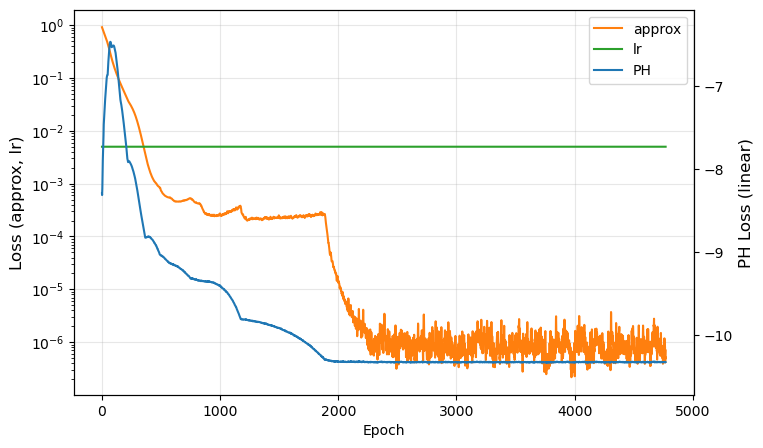

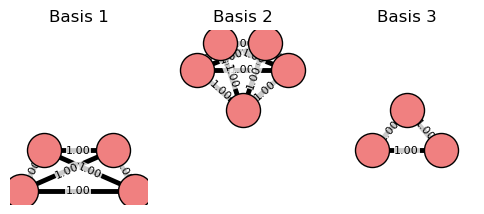

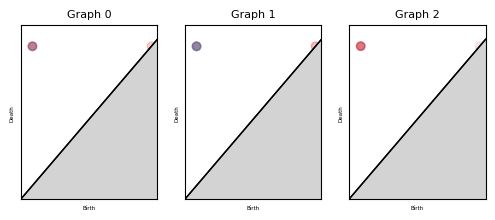

  0%|          | 0/5000 [00:00<?, ?it/s]

In [5]:
device = 'cpu'
n_components = 3

ph_complex = GraphFiltrationPH(max_dim=1, superlevel=True)

## specify target PH (or set to None for sparsity)
target_diagrams = [torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False),torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False)]

model = TopologicalNMF(
    n_components=n_components,
    device=device,
    random_state=43,
    complex=ph_complex,
    use_embedding=False,
    ph_loss_fn=clique_deviation_loss,
    ph_loss_params={"alpha": 1.0, 'remove_longest': {0: False, 1: False}}
)

model.fit(
    X,
    n_iterations=5000,
    lr=0.005,
    lambda_top=0.01,
    PH_dims=[0, 1],
    complex_inputs={'all_edges': all_edges, 'node_pos': fixed_pos},
    show_plots=['loss', 'PH', 'basis'],
    disp_interval=10,
    verbose=True,
    target_diagrams=target_diagrams,
    normalize_V_max = True,
    superlevel = True,
    init_method = 'random',
    plot_grid = (1,3)
)

plt.close('all')

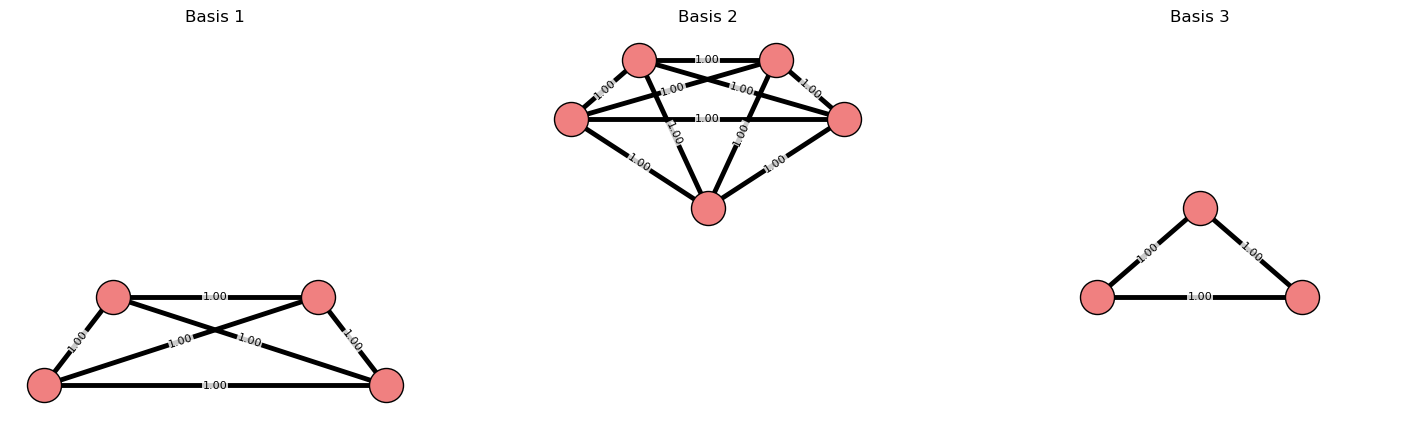

In [6]:
_=plot_gallery_graph(model.V.detach().cpu().numpy(), torch.Tensor(all_edges).T, title='Basis', pos=fixed_pos)